<a href="https://colab.research.google.com/github/aditi-tawade-ai/SkillBuilding/blob/main/Notebook/Day_32_KMeans_Employee.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler  # feature scaling
from sklearn.cluster import KMeans

In [ ]:
df = pd.read_csv('/content/Employee_income_1.csv')
df[:2]

,Name,Age,Income
0,Amit,27,70000
1,Akash,29,90000


In [ ]:
df.head()

,Name,Age,Income
0,Amit,27,70000
1,Akash,29,90000
2,Shriya,29,61000
3,Anita,28,62000
4,Sudhir,42,155000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Name    24 non-null     object
 1   Age     24 non-null     int64 
 2   Income  24 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 708.0+ bytes


In [ ]:
df.isna().sum()

,0
Name,0
Age,0
Income,0


<Axes: >

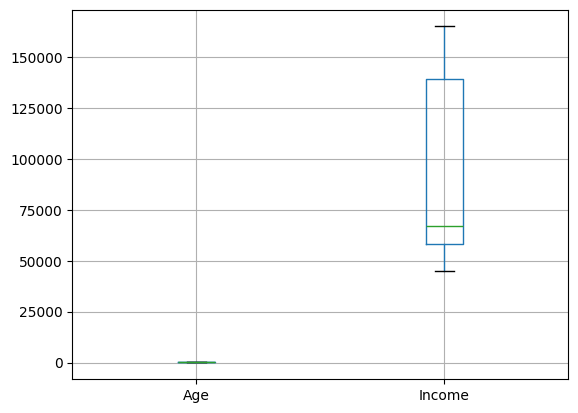

In [ ]:
df.boxplot()

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Income'}>]], dtype=object)

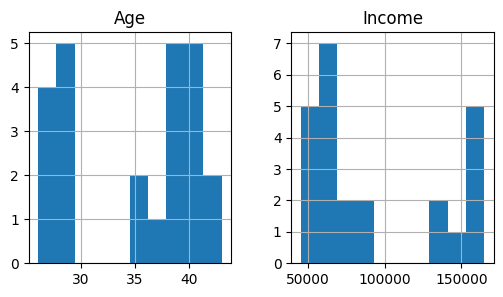

In [ ]:
df.hist(figsize=(6,3))

In [ ]:
X = df[['Age','Income']]
X[:2]

,Age,Income
0,27,70000
1,29,90000


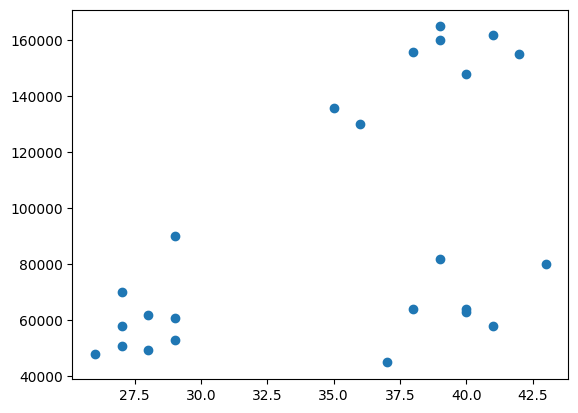

In [ ]:
plt.scatter(X['Age'],X['Income'])

<Axes: xlabel='Age', ylabel='Income'>

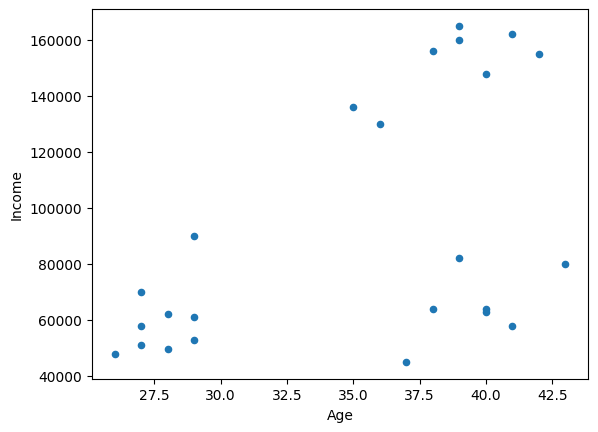

In [ ]:
df.plot.scatter(x='Age',y='Income')  # pandas plotting

In [ ]:
X.describe().T   # helps to check if theres noise/outliers

,count,mean,std,min,25%,50%,75%,max
Age,24.0,34.916667,5.933814,26.0,28.75,37.5,40.0,43.0
Income,24.0,92104.166667,44673.204489,45000.0,58000.00,67000.0,139000.0,165000.0


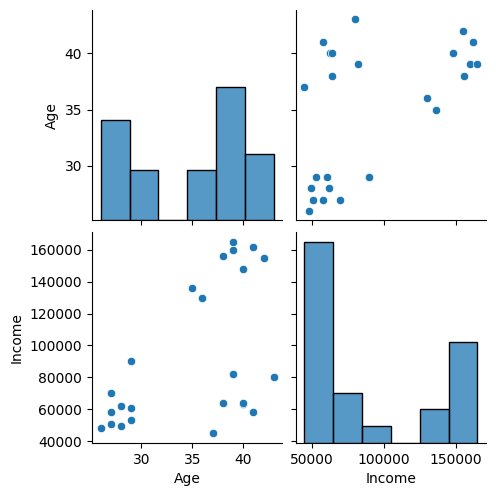

In [ ]:
sns.pairplot(df)

# Finding k using K means

In [ ]:
# default k means has 8 cluster
model = KMeans(n_clusters=3)

In [ ]:
model

KMeans(n_clusters=3)

In [ ]:
# training -  only x is used becoz unsupervised data has no output data
model.fit(X)

KMeans(n_clusters=3)

In [ ]:
model.cluster_centers_[:,:]   # cluster centroids

array([[3.4500e+01, 8.0500e+04],
       [3.8750e+01, 1.5150e+05],
       [3.2500e+01, 5.6375e+04]])

In [ ]:
X

,Age,Income
0,27,70000
1,29,90000
2,29,61000
3,28,62000
4,42,155000
5,39,160000
6,41,162000
7,38,156000
8,36,130000
9,35,136000


In [ ]:
model.cluster_centers_[:,:-1]   # age,income

array([[34.5 ],
       [38.75],
       [32.5 ]])

In [ ]:
model.cluster_centers_[:,-1:]

array([[ 80500.],
       [151500.],
       [ 56375.]])

In [ ]:
model.labels_    # it shows in which cluster the number is
# 0- cluster 1, 1- cluster 2,2- cluster 3

array([0, 0, 2, 2, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 1, 2, 2, 0, 0, 2, 2,
       2, 1], dtype=int32)

In [ ]:
model.predict(X)  # test the clusters are predicted right

array([0, 0, 2, 2, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 1, 2, 2, 0, 0, 2, 2,
       2, 1], dtype=int32)

In [ ]:
len(X)

24

In [ ]:
model

KMeans(n_clusters=3)

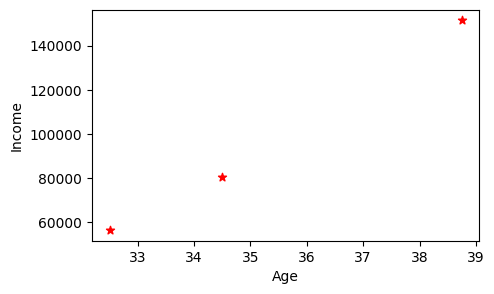

In [ ]:
# ploting centroids
plt.figure(figsize=(5,3))
plt.scatter(model.cluster_centers_[:,0],model.cluster_centers_[:,1],color='red',marker='*')
plt.xlabel('Age')
plt.ylabel('Income')
plt.show()

In [ ]:
# testing phase = this will train and predict the model
# it directly gives the cluster numbers for all X values
model.fit_predict(X)

array([2, 2, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 2, 2, 0, 0,
       0, 1], dtype=int32)

In [ ]:
# create a copy
x_new = X.copy()

In [ ]:
x_new[:2]

,Age,Income
0,27,70000
1,29,90000


In [ ]:
# adding cluster column in the data
X['cluster'] = model.fit_predict(X)
X[:3]

,Age,Income,cluster
0,27,70000,2
1,29,90000,2
2,29,61000,0


In [ ]:
X.shape

(24, 3)

In [ ]:
# create df for each cluster
df1 = X[X['cluster'] == 0]
df2 = X[X['cluster'] == 1]
df3 = X[X['cluster'] == 2]

In [ ]:
df1

,Age,Income,cluster
2,29,61000,0
3,28,62000,0
10,37,45000,0
11,26,48000,0
12,27,51000,0
13,28,49500,0
14,29,53000,0
16,40,63000,0
17,40,64000,0
20,41,58000,0


In [ ]:
df3[:3]

,Age,Income,cluster
0,27,70000,2
1,29,90000,2
18,43,80000,2


In [ ]:
df2[:3]

,Age,Income,cluster
4,42,155000,1
5,39,160000,1
6,41,162000,1


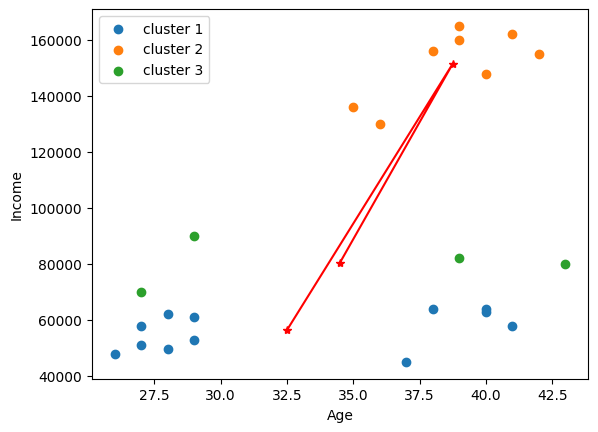

In [ ]:
# ploting the data of df1,df2,df3 with the centroides
plt.scatter(df1['Age'],df1['Income'],label='cluster 1')
plt.scatter(df2['Age'],df2['Income'],label='cluster 2')
plt.scatter(df3['Age'],df3['Income'],label='cluster 3')
plt.plot(model.cluster_centers_[:,0],model.cluster_centers_[:,1],color='red',marker='*')
plt.xlabel('Age')
plt.ylabel('Income')
plt.legend()   # to make visiblity of labels
plt.show()

- From above we can see that the clusters are not properly formed they are in the range of income
- So to reduce the dominance of income over age we will use feature scaling

In [ ]:
scaler = MinMaxScaler()
# formula = X - min(x) / max(x)-min(x)

In [ ]:
df['Income'] = scaler.fit_transform(df[['Income']])
df['Age'] = scaler.fit_transform(df[['Age']])

In [ ]:
df.head()   # in between probablity of 0 to 1

,Name,Age,Income
0,Amit,0.058824,0.208333
1,Akash,0.176471,0.375000
2,Shriya,0.176471,0.133333
3,Anita,0.117647,0.141667
4,Sudhir,0.941176,0.916667


In [ ]:
new_scale = MinMaxScaler()
# for both the columns it gives both ans together then we need to seperate it
# so better do it seperatly
new_scale.fit_transform(df[['Income','Age']])

array([[0.20833333, 0.05882353],
       [0.375     , 0.17647059],
       [0.13333333, 0.17647059],
       [0.14166667, 0.11764706],
       [0.91666667, 0.94117647],
       [0.95833333, 0.76470588],
       [0.975     , 0.88235294],
       [0.925     , 0.70588235],
       [0.70833333, 0.58823529],
       [0.75833333, 0.52941176],
       [0.        , 0.64705882],
       [0.025     , 0.        ],
       [0.05      , 0.05882353],
       [0.0375    , 0.11764706],
       [0.06666667, 0.17647059],
       [1.        , 0.76470588],
       [0.15      , 0.82352941],
       [0.15833333, 0.82352941],
       [0.29166667, 1.        ],
       [0.30833333, 0.76470588],
       [0.10833333, 0.88235294],
       [0.15833333, 0.70588235],
       [0.10833333, 0.05882353],
       [0.85833333, 0.82352941]])

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Income'}>]], dtype=object)

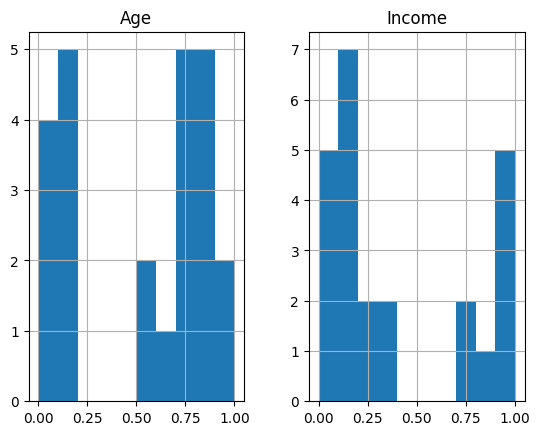

In [ ]:
df.hist()

In [ ]:
# now scaling is done create a new obj
km = KMeans(n_clusters=3)
km

KMeans(n_clusters=3)

In [ ]:
y_pred = km.fit_predict(df[['Age','Income']])   # predicted clusters
y_pred

array([1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 0, 1, 1, 1, 1, 2, 0, 0, 0, 0, 0, 0,
       1, 2], dtype=int32)

In [ ]:
km.labels_    # actual clusters

array([1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 0, 1, 1, 1, 1, 2, 0, 0, 0, 0, 0, 0,
       1, 2], dtype=int32)

In [ ]:
# lets add new column cluster in df
df['clusters'] = y_pred

In [ ]:
df[:3]

,Name,Age,Income,clusters
0,Amit,0.058824,0.208333,1
1,Akash,0.176471,0.375000,1
2,Shriya,0.176471,0.133333,1


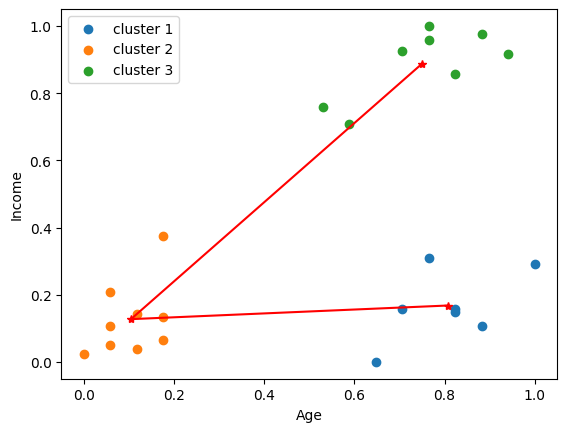

In [ ]:
# ploting the data for each clusters with centroids
# seperating clusters
df1 = df[df['clusters']==0]
df2 = df[df['clusters']==1]
df3 = df[df['clusters']==2]
# ploting
plt.scatter(df1['Age'],df1['Income'],label='cluster 1')
plt.scatter(df2['Age'],df2['Income'],label='cluster 2')
plt.scatter(df3['Age'],df3['Income'],label='cluster 3')
plt.plot(km.cluster_centers_[:,0],km.cluster_centers_[:,1],color='red',marker='*')
plt.xlabel('Age')
plt.ylabel('Income')
plt.legend()

- Now the centroides of cluster present in center

- Its showing correctly positioned centroides

# Part-II

In [ ]:
df[:2]

,Name,Age,Income,clusters
0,Amit,0.058824,0.208333,1
1,Akash,0.176471,0.375000,1


In [ ]:
km.predict([[16,150000]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


array([2], dtype=int32)

In [ ]:
km.predict([[45,1945000]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


array([2], dtype=int32)

In [ ]:
km.predict([[39,25000]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


array([2], dtype=int32)

- From above observations we can see all values are going in same cluster
- So we need to scale the predict value aswell

In [ ]:
# take random samples
test_data = df[['Age','Income']].sample(5)
test_data

,Age,Income
0,0.058824,0.208333
23,0.823529,0.858333
8,0.588235,0.708333
16,0.823529,0.150000
15,0.764706,1.000000


In [ ]:
km.predict(test_data)

array([1, 2, 2, 0, 2], dtype=int32)

In [ ]:
without_test = X.iloc[test_data.index,:-1]
without_test

,Age,Income
0,27,70000
23,40,148000
8,36,130000
16,40,63000
15,39,165000


In [ ]:
km.predict(without_test)

array([2, 2, 2, 2, 2], dtype=int32)

In [ ]:
display(test_data[:3],without_test[:3])

,Age,Income
0,0.058824,0.208333
23,0.823529,0.858333
8,0.588235,0.708333


,Age,Income
0,27,70000
23,40,148000
8,36,130000


In [ ]:
display(df[:2],X[:2])

,Name,Age,Income,clusters
0,Amit,0.058824,0.208333,1
1,Akash,0.176471,0.375000,1


,Age,Income,cluster
0,27,70000,2
1,29,90000,2


# WCSS - Within cluster sum of square

In [ ]:
km

KMeans(n_clusters=3)

In [ ]:
km.labels_

array([1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 0, 1, 1, 1, 1, 2, 0, 0, 0, 0, 0, 0,
       1, 2], dtype=int32)

In [ ]:
km.inertia_   # it changes as we change the cluster numbers
# inertia  =  wcss value

0.4920193431403064

In [ ]:
X = df[['Age','Income']]
X[:2]

,Age,Income
0,0.058824,0.208333
1,0.176471,0.375000


In [ ]:
k2 = KMeans(n_clusters=8)
k2.fit(X)
k2.inertia_
# less cluster more inertia value

0.1325991005062155

In [ ]:
# calculate inertia for clusters in range 1-10
wcss = []
for i in range(1,11):
  km = KMeans(n_clusters=i)
  km.fit(X)
  wcss.append(km.inertia_)

In [ ]:
wcss

[5.9897601858860385,
 2.418831568520655,
 0.4920193431403064,
 0.331177199093145,
 0.2563456831364082,
 0.2012594154491862,
 0.1625110259075035,
 0.11815685924083684,
 0.1099967410371011,
 0.07773132929642446]

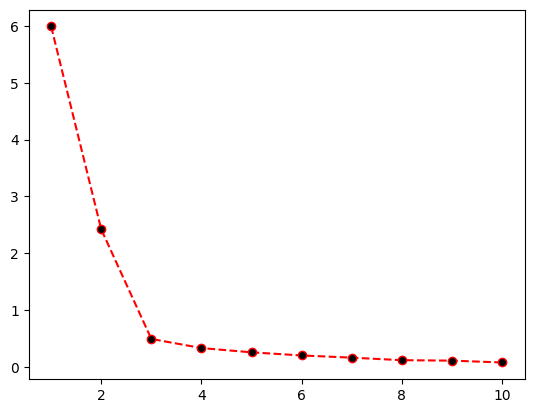

In [ ]:
plt.plot(range(1,11),wcss,linestyle='--',marker='o',color='r',mfc='k',markersize=6)


# **Silhoute Score**
- To measure the performance of Kmeans algo we use silhoute score

- It tells how good the clusters are
- It gives 3 values:
1. 0-Not good means clusters are close to each other
2. 1- Good clusters - clusters are seperate from each other
3. -1-Worst clustering clusters are mixing

In [ ]:
from sklearn.metrics import silhouette_score

In [ ]:
X[:3]

,Age,Income
0,0.058824,0.208333
1,0.176471,0.375000
2,0.176471,0.133333


In [ ]:
new = KMeans(n_clusters=3)
new.fit(X)

KMeans(n_clusters=3)

In [ ]:
new.labels_

array([1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 2, 1, 1, 1, 1, 0, 2, 2, 2, 2, 2, 2,
       1, 0], dtype=int32)

In [ ]:
# to calculate silhoute score we need i/p and its clusters
silhouette_score(X,new.labels_)

np.float64(0.7261322509367406)

In [ ]:
score = []
for i in range(2,11):
  new = KMeans(n_clusters=i)
  new.fit(X)
  print('Cluster:',i,'Score:',silhouette_score(X,new.labels_))
  #score.append(silhouette_score(X,new.labels_))

Cluster: 2 Score: 0.5371159667908988
Cluster: 3 Score: 0.7261322509367406
Cluster: 4 Score: 0.6179513263592575
Cluster: 5 Score: 0.5989901496296245
Cluster: 6 Score: 0.4776894740699508
Cluster: 7 Score: 0.40012496901949374
Cluster: 8 Score: 0.42795862834199866
Cluster: 9 Score: 0.32386388026048435
Cluster: 10 Score: 0.33576807998652014


From above we can see that silhoutte score is good for cluster no. 3